# Eye irritation model

In [11]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, roc_curve, auc, roc_auc_score, accuracy_score
import pickle 
from rdkit import Chem, RDLogger
from rdkit.Chem import MACCSkeys, AllChem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold
RDLogger.DisableLog('rdApp.*')
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV, StratifiedKFold

## Load data

In [3]:
df = pd.read_csv('irritation.csv')
df.head()

,SMILES,Class
0,CC#CC,1
1,CCC=C,1
2,O=CC=O,1
3,CCC=O,1
4,FCC#N,1


### Dataset description 

Unlike corneal permeability and melanin binding, the eye irritation labels are taken **as-is from the source (in silico predictions, Wang et al.)** — no re-thresholding or class balancing was performed by us.

In [4]:
print('Total compounds:', len(df))
print('Duplicated SMILES:', df['SMILES'].duplicated().sum())
print()
print(df['Class'].value_counts())
print('Class balance:', df['Class'].mean().round(3))

Total compounds: 5220
Duplicated SMILES: 0

Class
1    3874
0    1346
Name: count, dtype: int64
Class balance: 0.742


### Converting to MACCS fp

In [5]:
smiles = df['SMILES'].to_list()

In [6]:
def smiles_to_maccs(smiles_list):
    mols = [Chem.MolFromSmiles(s) for s in smiles_list]

    valid_idx = [i for i, m in enumerate(mols) if m is not None]
    mols = [mols[i] for i in valid_idx]
    smiles_valid = [smiles_list[i] for i in valid_idx]

    maccs_list = []
    for mol in mols:
        bits = list(MACCSkeys.GenMACCSKeys(mol).ToBitString())
        maccs_list.append(bits)

    header = [f'bit{i}' for i in range(167)]
    df_out = pd.DataFrame(maccs_list, columns=header).astype(int)
    df_out.insert(0, 'SMILES', smiles_valid)

    return df_out

In [7]:
df2 = smiles_to_maccs(smiles)

/var/folders/d0/t960n9f12vv86tmxqy62k3r40000gn/T/ipykernel_9812/2940242413.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_out.insert(0, 'SMILES', smiles_valid)


In [8]:
X = df2.iloc[:, 1:168].astype(int)
y = np.array(df[['Class']]).ravel()

In [9]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=10)

### Train model

In [12]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [3, 5, 8],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 4, 10],
    "max_features": ["sqrt", "log2"],
    "subsample": [0.5, 0.8, 1.0],
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [16]:
grid_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=100,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

grid_search.fit(Xtrain, ytrain)

Fitting 10 folds for each of 100 candidates, totalling 1000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be

In [17]:
best_gb = grid_search.best_estimator_
print(grid_search.best_params_)
print(f"best CV F1 = {grid_search.best_score_:.3f}")

{'subsample': 1.0, 'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 5, 'learning_rate': 0.1}
best CV F1 = 0.962


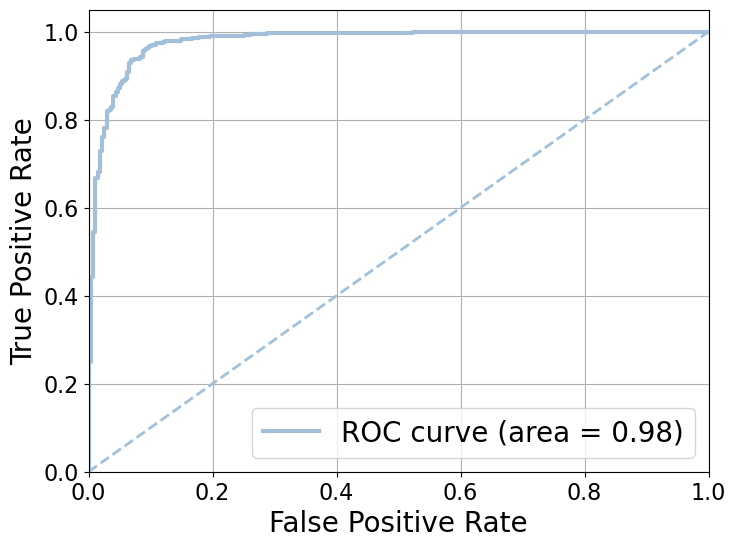

In [19]:
y_pred = best_gb.predict_proba(Xtest)[:, 1]

fpr, tpr, thresholds = roc_curve(ytest, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr, tpr, 
    color='#A2C0D9', 
    label='ROC curve (area = {:.2f})'.format(roc_auc),
    linewidth=3
)

plt.plot(
    [0, 1], [0, 1], 
    color='#A2C0D9', 
    linestyle='--', 
    linewidth=2
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=20)
plt.ylabel('True Positive Rate', fontsize=20)
plt.legend(loc='lower right', fontsize=20)
plt.tick_params(axis='both', labelsize=16)

plt.grid()
plt.savefig('irr_ML.svg', dpi=700, bbox_inches='tight')
plt.show()

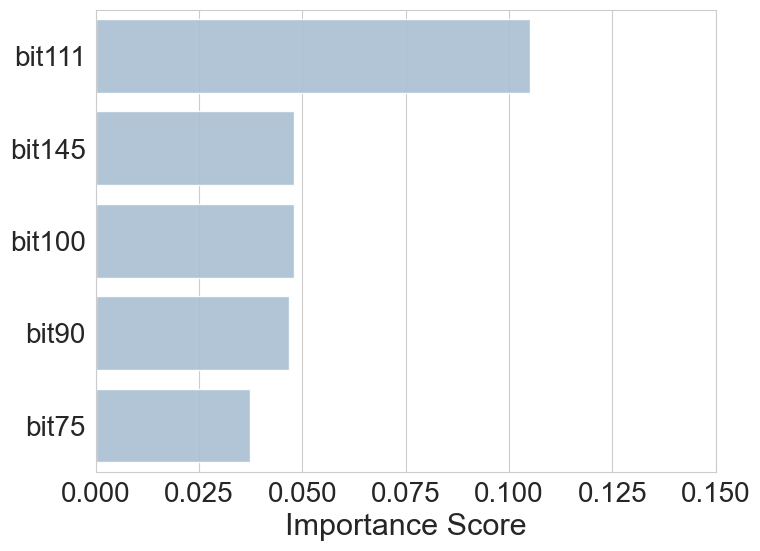

In [26]:
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_gb.feature_importances_
}).sort_values(by='Importance', ascending=False)

top5_df = feature_importance_df.head(5)

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

bar_color = '#A2C0D9'
sns.barplot(x='Importance', y='Feature', data=top5_df, color=bar_color, alpha=0.9)

plt.xlabel('Importance Score', fontsize=22)
plt.ylabel('')
plt.xlim(0,0.15)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.savefig('irr_FI.svg', dpi=700, bbox_inches='tight')
plt.show()

### Save model

In [21]:
pkl_filename = "irritation.pkl"

In [22]:
with open(pkl_filename, 'wb') as file: 
    pickle.dump(best_gb, file)

## Scaffold split 

In [23]:
def morgan_fp(smi, radius=2, nbits=2048):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nbits)

def scaffold_of(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    try:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaf)
    except Exception:
        return None

def scaffold_split(smiles_list, test_size=0.2, seed=42):
    scaffolds = {}
    for idx, smi in enumerate(smiles_list):
        s = scaffold_of(smi)
        scaffolds.setdefault(s, []).append(idx)
    groups = list(scaffolds.values())
    rng = np.random.RandomState(seed)
    order = rng.permutation(len(groups))
    groups = [groups[i] for i in order]
    groups.sort(key=len, reverse=True)
    n_total = len(smiles_list)
    n_test_target = int(round(n_total * test_size))
    test_idx, train_idx = [], []
    for g in groups:
        if len(test_idx) < n_test_target:
            test_idx.extend(g)
        else:
            train_idx.extend(g)
    return np.array(train_idx), np.array(test_idx)

def nn_tanimoto_stats(train_smiles, test_smiles):
    train_fps = [morgan_fp(s) for s in train_smiles]
    train_fps = [f for f in train_fps if f is not None]
    sims = []
    for s in test_smiles:
        fp = morgan_fp(s)
        if fp is None or len(train_fps) == 0:
            continue
        bulk = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
        sims.append(max(bulk))
    sims = np.array(sims)
    return {
        'mean_NN_Tanimoto': float(np.mean(sims)) if len(sims) else np.nan,
        'median_NN_Tanimoto': float(np.median(sims)) if len(sims) else np.nan,
        'frac_test_with_NN>0.85': float(np.mean(sims > 0.85)) if len(sims) else np.nan,
    }

In [24]:
smiles_valid = df2['SMILES'].values
X_all = df2.iloc[:, 1:168].astype(int).values
y_all = df.set_index('SMILES').loc[smiles_valid, 'Class'].values
idx_all = np.arange(len(smiles_valid))

def eval_split(train_idx, test_idx, label):
    model = GradientBoostingClassifier(learning_rate=0.1, max_depth=8, max_features='sqrt',
                                        min_samples_leaf=10, subsample=0.5, random_state=10)
    model.fit(X_all[train_idx], y_all[train_idx])
    proba = model.predict_proba(X_all[test_idx])[:,1]
    pred = model.predict(X_all[test_idx])
    auc_ = roc_auc_score(y_all[test_idx], proba)
    f1_ = f1_score(y_all[test_idx], pred)
    acc_ = accuracy_score(y_all[test_idx], pred)
    sims = nn_tanimoto_stats(smiles_valid[train_idx], smiles_valid[test_idx])
    print(f"--- {label} ---")
    print(f"  n_train={len(train_idx)} n_test={len(test_idx)} train_pos_frac={y_all[train_idx].mean():.2f} test_pos_frac={y_all[test_idx].mean():.2f}")
    print(f"  ROC-AUC={auc_:.3f}  F1={f1_:.3f}  Acc={acc_:.3f}")
    print(f"  NN-Tanimoto: mean={sims['mean_NN_Tanimoto']:.3f} median={sims['median_NN_Tanimoto']:.3f} "
          f"frac>0.85={sims['frac_test_with_NN>0.85']:.2f}")
    return dict(label=label, auc=auc_, f1=f1_, acc=acc_, **sims)

results = []
tr, te = train_test_split(idx_all, test_size=0.2, random_state=10, stratify=y_all)
results.append(eval_split(tr, te, "Random split (orig, seed=10)"))

tr_s, te_s = scaffold_split(smiles_valid, test_size=0.2, seed=42)
results.append(eval_split(tr_s, te_s, "Scaffold split"))

pd.DataFrame(results)

--- Random split (orig, seed=10) ---
  n_train=4176 n_test=1044 train_pos_frac=0.74 test_pos_frac=0.74
  ROC-AUC=0.964  F1=0.956  Acc=0.934
  NN-Tanimoto: mean=0.565 median=0.565 frac>0.85=0.06
--- Scaffold split ---
  n_train=3673 n_test=1547 train_pos_frac=0.67 test_pos_frac=0.92
  ROC-AUC=0.953  F1=0.978  Acc=0.959
  NN-Tanimoto: mean=0.460 median=0.455 frac>0.85=0.00


,label,auc,f1,acc,mean_NN_Tanimoto,median_NN_Tanimoto,frac_test_with_NN>0.85
0,"Random split (orig, seed=10)",0.964096,0.955967,0.933908,0.564656,0.565217,0.059387
1,Scaffold split,0.952797,0.978072,0.959276,0.459578,0.454545,0.000000
